In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/cvd_synthetic_dataset_v0.2.csv')

## Summary of EDA findings

The exploratory analysis reveals a dataset that is broadly well-structured and clinically coherent, with several important findings that will inform preprocessing and modelling decisions:

- Age is the dominant predictor, with a striking concentration of events in older patients
- Atrial fibrillation, CKD, diabetes, and rheumatoid arthritis show the strongest associations with the outcome among binary variables
- Smoker and hypertension_treated show minimal predictive signal, likely reflecting deliberate noise in the synthetic dataset
- BMI and FEV1 have significant missingness (30% and 70% respectively) requiring careful handling
- The dataset is heavily imbalanced (6.6% event rate), requiring class weighting during training
- No severe multicollinearity was identified, supporting the use of logistic regression

## Preprocessing

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Drop columns not used in model
df_model = df.drop(columns=['patient_id', 'time_to_event_or_censoring'])

# Encode gender
df_model['gender'] = df_model['gender'].map({'M': 1, 'F': 0})

# Separate features and target
X = df_model.drop(columns=['heart_attack_or_stroke_occurred'])
y = df_model['heart_attack_or_stroke_occurred']

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Scale continuous variables
scaler = StandardScaler()
continuous_cols_model = ['age', 'body_mass_index', 'systolic_blood_pressure', 'forced_expiratory_volume_1']
X_imputed[continuous_cols_model] = scaler.fit_transform(X_imputed[continuous_cols_model])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set: {X_test.shape[0]} patients")
print(f"Event rate in training set: {y_train.mean().round(3) * 100}%")
print(f"Event rate in test set: {y_test.mean().round(3) * 100}%")

Training set: 80000 patients
Test set: 20000 patients
Event rate in training set: 6.6000000000000005%
Event rate in test set: 6.6000000000000005%


### Preprocessing steps

The following preprocessing steps were applied prior to model training:

**Dropped columns:** `patient_id` (identifier only) and `time_to_event_or_censoring` (relevant to survival analysis only, not binary classification).

**Gender encoding:** Categorical gender variable encoded as binary (M=1, F=0).

**Missing value imputation:** Median imputation applied to `body_mass_index` (30% missing), `systolic_blood_pressure` (10% missing), and `forced_expiratory_volume_1` (70% missing). Median imputation is appropriate given the approximately normal distributions observed in EDA. A more sophisticated approach such as multiple imputation could be explored in future work.

**Feature scaling:** Continuous variables scaled using StandardScaler (zero mean, unit variance). This is required for logistic regression, which is sensitive to the scale of input features — without scaling, age in years would dominate purely due to its numeric range relative to binary variables.

**Train/test split:** 80/20 stratified split applied, preserving the 6.6% event rate in both subsets. The random state is fixed at 42 for reproducibility.

## Model training

### Logistic regression

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, 
                             RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay)

# Train model
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

# Results
print(f"AUC-ROC: {round(roc_auc_score(y_test, y_prob), 3)}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['No event', 'Event']))

AUC-ROC: 0.833

Classification report:
              precision    recall  f1-score   support

    No event       0.98      0.73      0.83     18678
       Event       0.17      0.80      0.28      1322

    accuracy                           0.73     20000
   macro avg       0.58      0.76      0.56     20000
weighted avg       0.93      0.73      0.80     20000



### Logistic regression results

**AUC-ROC: 0.833** — the model demonstrates good discriminative ability, correctly ranking a patient who will experience an event above one who will not in 83.3% of cases.

**Sensitivity (recall) for events: 0.80** — the model correctly identifies 80% of patients who will go on to have a heart attack or stroke. In a screening context this is the most clinically important metric — the model catches 4 in 5 true cases.

**Specificity: 0.73** — 73% of patients who will not have an event are correctly classified as low risk. The remaining 27% are false positives — patients flagged as high risk who will not actually have an event. In a primary care screening context, this is the more acceptable error: a false positive leads to further investigation or preventive treatment, whereas a false negative leads to a missed event.

**Precision for events: 0.17** — of all patients the model flags as high risk, only 17% will actually have an event. This low precision is expected given the heavy class imbalance (6.6% event rate) and the use of class_weight='balanced', which deliberately prioritises sensitivity over precision. In a real deployment, the classification threshold would be tuned to balance these tradeoffs based on clinical context.

**Overall accuracy: 0.73** — this figure is misleading in isolation given the class imbalance and should not be used as the primary evaluation metric.

C:\Users\Aaron\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


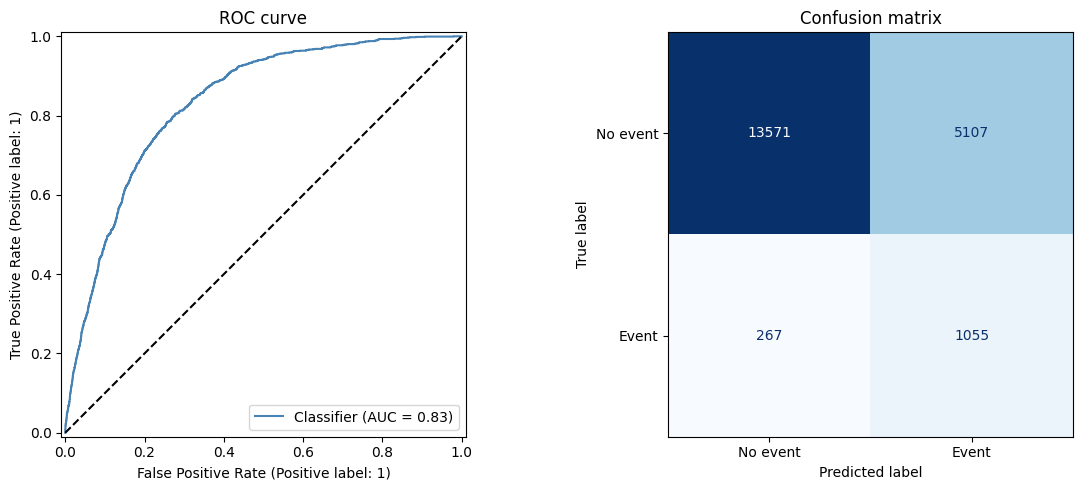

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC curve')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No event', 'Event'],
    ax=axes[1],
    colorbar=False,
    cmap='Blues'
)
axes[1].set_title('Confusion matrix')

plt.tight_layout()
plt.show()

### ROC curve and confusion matrix

**ROC curve:** The curve bows strongly towards the top-left corner, well above the diagonal dashed line which represents a model with no predictive ability (random guessing). The AUC of 0.83 confirms strong discriminative performance.

**Confusion matrix — breaking down the 20,000 test patients:**

- **True negatives: 13,571** — correctly identified as low risk
- **True positives: 1,055** — correctly identified as high risk
- **False positives: 5,107** — incorrectly flagged as high risk (will not have an event)
- **False negatives: 267** — missed cases; patients who will have an event but were classified as low risk

**Clinical interpretation:** The model misses 267 out of 1,322 true events — a false negative rate of 20%. In a primary care screening context, these represent patients who would not be referred for further investigation or preventive treatment despite being at genuine risk. The 5,107 false positives represent patients who would be unnecessarily investigated, carrying a cost burden but not direct patient harm. Whether this tradeoff is acceptable depends on the clinic

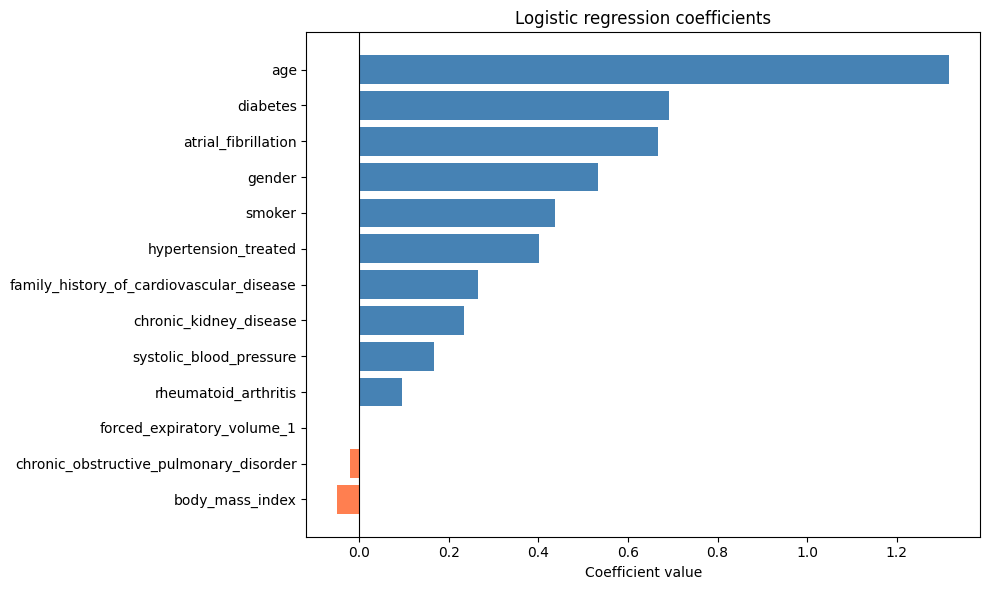

                                 feature  coefficient
                                     age     1.317838
                                diabetes     0.690985
                     atrial_fibrillation     0.667765
                                  gender     0.534053
                                  smoker     0.437232
                    hypertension_treated     0.402344
family_history_of_cardiovascular_disease     0.265732
                  chronic_kidney_disease     0.233998
                 systolic_blood_pressure     0.167631
                    rheumatoid_arthritis     0.094830
              forced_expiratory_volume_1    -0.000271
  chronic_obstructive_pulmonary_disorder    -0.020405
                         body_mass_index    -0.049824


In [6]:
# Feature importance from logistic regression coefficients
coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in coefficients['coefficient']]
ax.barh(coefficients['feature'], coefficients['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic regression coefficients')
ax.set_xlabel('Coefficient value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(coefficients.to_string(index=False))

### Feature importance — logistic regression coefficients

Positive coefficients increase predicted risk; negative coefficients decrease it. Features have been scaled so coefficients are directly comparable.

**Age (1.32)** is by far the dominant predictor, consistent with all EDA findings and with QRISK3, where age is the single most important variable. The coefficient is nearly double that of any other feature.

**Diabetes (0.69) and atrial fibrillation (0.67)** are the next strongest predictors — both clinically expected given their well-established roles as independent CVD risk factors.

**Gender (0.53)** — encoded as male=1 — confirms that male sex increases predicted risk, consistent with the known earlier onset of CVD in men.

**Smoker (0.44)** shows a positive coefficient despite the near-zero event rate difference observed in EDA. This apparent contradiction likely reflects the model detecting a genuine signal when controlling for other variables — smoking's effect may be masked in raw event rates by its correlation with other factors. Alternatively this may reflect the model overfitting to noise in a synthetic variable. Worth flagging.

**Hypertension treated (0.40)** has a positive coefficient despite its negative correlation with SBP. This is clinically logical — being on antihypertensive treatment is a marker of underlying vascular disease burden, not a protective factor in itself. The model has correctly learned that treated hypertension represents elevated risk even when SBP appears controlled.

**FEV1 (-0.0003), COPD (-0.02), and BMI (-0.05)** are essentially zero or slightly negative — confirming these variables carry minimal independent predictive signal in this dataset. BMI's negative coefficient is a synthetic data artefact and would not be expected in real-world data.

### Model interpretability — SHAP values

SHAP (SHapley Additive exPlanations) values explain the contribution of each feature to individual predictions, rather than just the global coefficients. This moves beyond "which features matter overall" to "why did the model predict high risk for this specific patient".

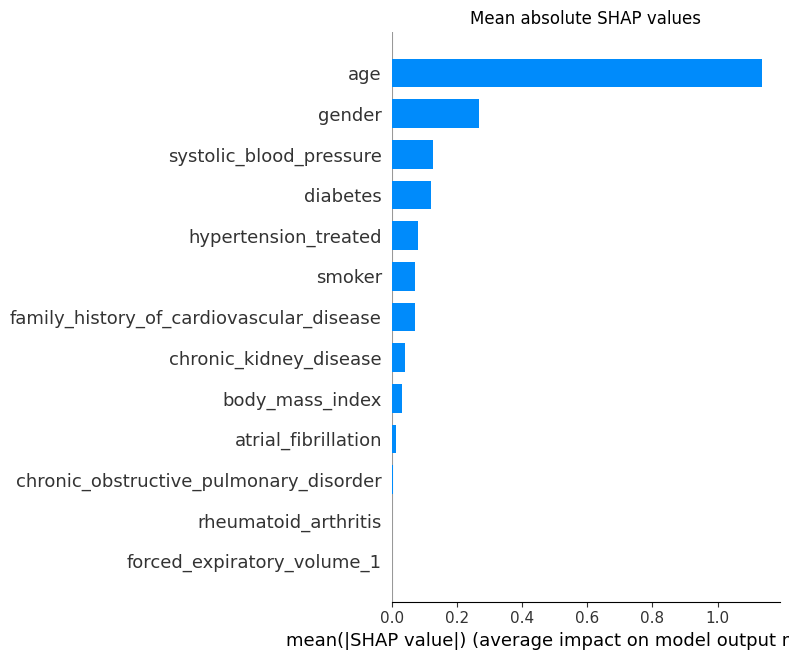

In [7]:
import shap

explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean absolute SHAP values')
plt.tight_layout()
plt.show()

### SHAP value interpretation

SHAP values measure average impact on model output across all test patients, accounting for the actual distribution of each feature in the data. This differs from raw coefficients, which reflect the model's learned weights in isolation.

**Age (1.13)** remains overwhelmingly dominant — consistent with coefficients and EDA. No surprise here.

**Gender (0.27)** ranks second in SHAP importance, higher than its coefficient ranking suggested. This reflects the fact that gender is present for all 20,000 test patients with no missingness, so its impact accumulates across the entire population.

**Systolic blood pressure and diabetes** rank third and fourth — both clinically expected strong predictors.

**Atrial fibrillation** drops significantly in SHAP ranking compared to its coefficient position. This is explained by its low prevalence (1.1%) — despite having a large coefficient, AF only affects a small number of patients, so its average impact across the full population is modest. This is an important distinction: AF is a strong predictor for the patients who have it, but its population-level impact is limited by its rarity.

**COPD, rheumatoid arthritis, and FEV1** show near-zero SHAP values, confirming they contribute almost nothing to predictions in practice.

**Clinical implication:** The model is predominantly driven by age, gender, and to a lesser extent SBP and diabetes — a variable set broadly consistent with the core components of established CVD risk tools. The dominance of age in particular means the model should be interpreted cautiously in younger patients with multiple comorbidities, where age alone may underweight their true risk.

## Critical appraisal

### Model performance in context

An AUC-ROC of 0.83 represents good discriminative performance for a simple logistic regression model trained on a modest variable set. For context, QRISK3 achieves an AUC of approximately 0.88 in validation studies, using a considerably richer variable set including cholesterol, deprivation scores, and more granular comorbidity data. The performance gap is therefore expected and reflects the limitations of the available variables rather than a fundamental failure of the modelling approach.

### Dataset limitations

**Synthetic data:** The dataset was simulated rather than derived from real patient records. While designed to reflect real-world complexity, synthetic data cannot fully capture the heterogeneity of NHS primary care populations — particularly variation by ethnicity, deprivation, and geography, all of which are meaningful CVD risk modifiers in England.

**Missing variables:** The dataset does not include cholesterol or lipid data, deprivation scores (Townsend index), or ethnicity — all of which are included in QRISK3 and contribute meaningfully to cardiovascular risk prediction. Their absence limits the model's predictive ceiling.

**Smoking encoding:** The boolean smoker variable does not distinguish between current and ex-smokers, which carry substantially different risk profiles in clinical practice and in QRISK3.

**Diabetes encoding:** No distinction between Type 1 and Type 2 diabetes, which have different cardiovascular risk mechanisms and magnitudes.

**FEV1 missingness:** 70% missing data in forced_expiratory_volume_1 severely limits its contribution to the model despite its clinical relevance.

### Generalisability to NHS practice

This model was trained on a synthetic dataset modelled on UK primary care data, which is a strength relative to US-derived datasets commonly used in ML portfolios. However, several barriers would need to be addressed before any real-world deployment could be considered:

**Regulatory pathway:** Under MHRA guidance, an AI tool used to inform clinical risk decisions would likely be classified as a Software as a Medical Device (SaMD), requiring conformity assessment and clinical validation before deployment in the NHS.

**Clinical validation:** The model would require prospective validation on real patient data from diverse NHS populations before any clinical use could be considered.

**Equity and fairness:** The model has not been assessed for differential performance across demographic subgroups. CVD risk tools have historically performed less well in South Asian and Black populations — a critical consideration for any NHS deployment.

**Explainability requirements:** NHS AI Lab guidance emphasises the importance of explainable AI in clinical settings. Logistic regression is inherently interpretable, which is an advantage over black-box approaches, and SHAP values further support individual-level explanation.

### Conclusion

This project demonstrates the application of logistic regression to cardiovascular risk prediction in a UK primary care context, achieving clinically meaningful discriminative performance (AUC 0.83) using a transparent and interpretable modelling approach. The methodology is broadly consistent with established CVD risk tools and the findings are clinically coherent throughout. Significant work would be required before any real-world application, including access to richer data, prospective clinical validation, regulatory assessment, and equity analysis.